In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import math

In [3]:
df1 = pd.read_csv('../data/data_final_with_aadt.csv')

In [4]:
df_bridges = df1[df1['model_type'] == 'bridge']
df_bridges = df_bridges.sort_values(by = 'avg_truck_AADT', ascending = False)


In [5]:
df_bridges

,Unnamed: 0,road,id,model_type,condition,name,lat,lon,length,avg_truck_AADT
8,8,N1,100009,bridge,B,NaN,23.696400,90.535099,8.0,2872.333333
10,10,N1,100011,bridge,A,NaN,23.694391,90.537574,6.3,2872.333333
12,12,N1,100013,bridge,A,NaN,23.694302,90.537707,6.3,2872.333333
14,14,N1,100015,bridge,A,NaN,23.692360,90.540918,8.3,2872.333333
16,16,N1,100017,bridge,B,NaN,23.690912,90.545462,10.6,2872.333333
...,...,...,...,...,...,...,...,...,...,...
1698,1698,N106,101699,bridge,C,NaN,22.616409,92.102485,3.0,73.000000
1696,1696,N106,101697,bridge,A,NaN,22.612030,92.101655,11.0,73.000000
1694,1694,N106,101695,bridge,A,NaN,22.610977,92.099918,1.0,73.000000
1692,1692,N106,101693,bridge,A,NaN,22.609506,92.097489,1.0,73.000000


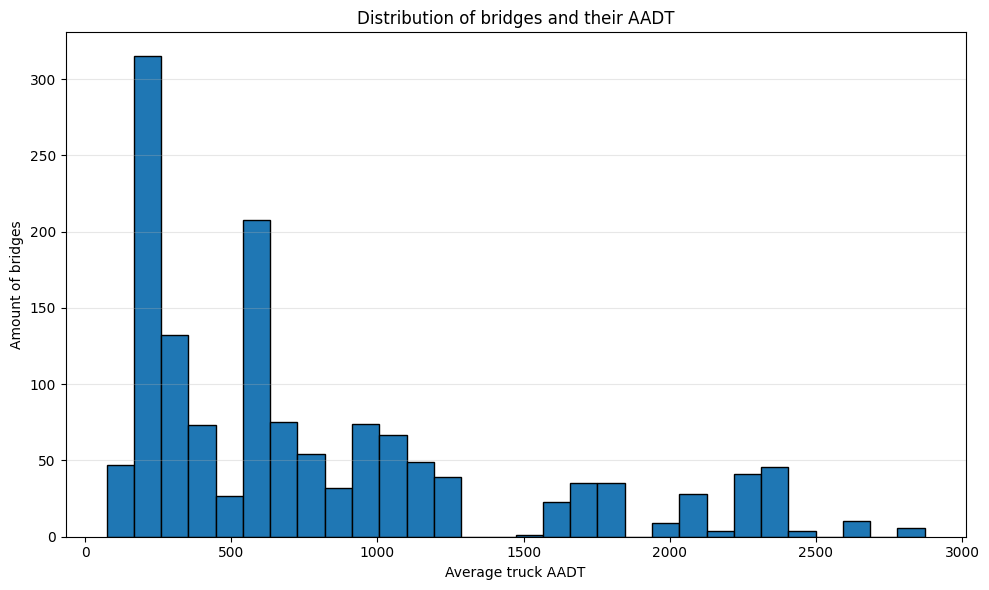

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(df_bridges['avg_truck_AADT'], bins=30, edgecolor='black')
plt.title('Distribution of bridges and their AADT')
plt.xlabel('Average truck AADT')
plt.ylabel('Amount of bridges')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
#Bridges with top 5% highest average truck AADT
n_top = math.ceil(len(df_bridges) * 0.05)

#Select bridge with smallest AADT in n_top
cutoff_aadt = df_bridges.iloc[n_top - 1]['avg_truck_AADT']

#Select all bridges with AADT that are higher or equal to the smallest AADT bridge in n_top
top_bridges = df_bridges[df_bridges['avg_truck_AADT'] >= cutoff_aadt]

print("Amount of selected bridges", len(top_bridges))
print(top_bridges.head())

Amount of selected bridges 92
    Unnamed: 0 road      id model_type condition name        lat        lon  \
8            8   N1  100009     bridge         B  NaN  23.696400  90.535099   
10          10   N1  100011     bridge         A  NaN  23.694391  90.537574   
12          12   N1  100013     bridge         A  NaN  23.694302  90.537707   
14          14   N1  100015     bridge         A  NaN  23.692360  90.540918   
16          16   N1  100017     bridge         B  NaN  23.690912  90.545462   

    length  avg_truck_AADT  
8      8.0     2872.333333  
10     6.3     2872.333333  
12     6.3     2872.333333  
14     8.3     2872.333333  
16    10.6     2872.333333  


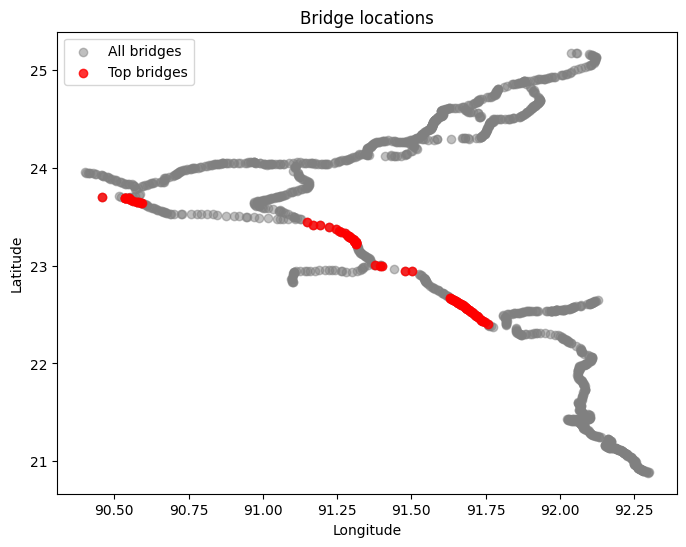

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(df_bridges['lon'], df_bridges['lat'],
            color='gray', alpha=0.5, label='All bridges')

plt.scatter(top_bridges['lon'], top_bridges['lat'],
            color='red', alpha=0.8, label='Top bridges')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Bridge locations')
plt.legend()

plt.show()